# 31 - Heretical & coercive natalism fanout (E34, H314-H338)

**Author**: kj  **Approach**: model-as-judge; the path integral is the judge of coercion

This round goes to the edge of the design space - the coercive, zealous, theocratic and structural
levers decent policy discourse refuses to say out loud - and grounds each in a real historical analogue.
The unifying question: **does zeal buy fertility that cash cannot, through which channel, and at what
cost across generations?** Every "religion / decree / medal" is a **bundle** on the model's own channels -
norm `N`, coupling `C`, parity `P̄`, tempo `τ`, childlessness `ρ`, security `S` - plus a defection fraction
`δ` (evasion) and the two E30 path-integral channels father-investment `fF` and relationship-scar `fScar`.

The round's headline is the **coercion × path-integral sign flip**. A coercive lever forces gen-1 births
into a **scarred childhood environment** (`fScar↑`, `fF↓`); `ot.CohortMemory` carries that damage forward
27-45 years into depressed marriageability `q` and coupling `C`, so the gen-1 boost **reverses** by gen-3-4.
Devotion and structural levers force births into **healthy, freely-chosen** environments and transmit a
pronatal norm forward, so they **hold or compound**. No static ΔTFR can see either - that is why the round
needed the cohort path integral. **Coercion can win the first generation and lose the third.**

**Sign convention** (fertility-raising push): `fN↓` pronatal norm, `fRV↓` less childlessness, `fTau↓`
earlier, `fPb↑` higher parity, `fS↑` security/community, `fC↑` coupling, `fF↑` father investment,
`fScar↓` less conflict. `δ` attenuates the removable channels; `fF/fScar` carry the cross-generational sign.

**Output**: `reports/figures/nb31_coercion_reversal.png`, `nb31_norm_penalty.png`, `nb31_fate_table.png`,
`reports/nb31_e34_verdicts.json`, `nb31_heretical_table.csv`. Grounded in
`references/papers/e34-heretical-fanout-digest.md`. Digest lean 3 SUPPORTED / 11 PARTIAL / 11 REFUTED;
the model supplies the earned verdict. Campaign total 338 → 348 (E35's 10 already reserved).

## GPU selection

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-58ae1f45-295c-681b-60ad-843265f52997"
import numpy as np, torch, json, csv
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib as mpl
from matplotlib.patches import Patch
from rich import print as rprint
from rich.panel import Panel
from rich.table import Table
torch.set_default_dtype(torch.float64)
mpl.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
rprint(f"[green]Device[/green]: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'}")

Device: NVIDIA RTX PRO 4000 Blackwell

## Configuration - the calibrated distributional core with the E30 path integral

All hypotheses are scored on `run_cal` (the dispersed K-agent ensemble re-anchored to 2023 REAL TFR), the
production run that carries the norm `N`, marriageability `q`, and the per-cohort childhood-environment path
integral. Each hypothesis maps a digest channel vector to a 9-channel forcing: the removable behavioural
channels are attenuated by `(1-δ)` (severity without certainty is weak deterrence - people evade), while the
path-integral channels `fF/fScar` enter at full strength because they encode the *quality of the environment*
the forced or freely-chosen births land in. Generations are read at 2050 (gen-1) and 2124 (gen-4).

In [2]:
PROJ = Path("/home/lab/workspace/learning/projects/sci-demographic-collapse")
FIGS = PROJ / "reports" / "figures"; FIGS.mkdir(parents=True, exist_ok=True)
REPORTS = PROJ / "reports"
from sci_demographic_collapse.emergent import EmergentModel, ramp, erode, PARAMS, REAL
m = EmergentModel(data_dir=str(PROJ / "data" / "raw" / "unwpp"))
TRIAD = ["Korea", "Germany", "France"]; C_THR = PARAMS["C_thr"]
YR = np.arange(2023, 2125); idx = lambda y: int(np.argmin(abs(YR - y)))
GEN1, GEN4 = idx(2050), idx(2124)  # ~gen-1 and ~gen-4 on a 27-30yr generation
BASE = {r: m.run_cal(r) for r in TRIAD}
IDX = {"fS": 0, "fC": 1, "fPb": 2, "fTau": 3, "fRV": 4, "fN": 5, "fq": 6, "fF": 7, "fScar": 8}
# removable behavioural channels attenuated by (1-delta); fF/fScar carry the environment at full strength
REMOVABLE = {"fS", "fC", "fPb", "fTau", "fRV", "fN", "fq"}

def force_of(H, start=0):
    # 9-channel forcing: delta attenuates removable channels; fF/fScar carry the environment at full strength
    d = 1.0 - H.get("delta", 0.0)
    def fy(yr):
        s = ramp(yr, start=start, d=10)
        f = [0.0] * 9
        for k, v in H["f"].items():
            f[IDX[k]] += v * (d if k in REMOVABLE else 1.0) * s
        f[IDX["fF"]] += H.get("fF", 0.0) * s
        f[IDX["fScar"]] += H.get("fScar", 0.0) * s
        return f
    return fy

def gens(region, H):
    # gen-1 (2050) and gen-4 (2124) delta-TFR vs baseline for one region
    b = BASE[region]; t = m.run_cal(region, force_of(H))
    return t["TFR"][GEN1] - b["TFR"][GEN1], t["tfr"] - b["tfr"], t
rprint("[green]calibrated distributional core + E30 path integral ready[/green]")

2026-07-08 13:10:38.355 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


calibrated distributional core + E30 path integral ready

## Calibration re-check - the baseline must be a fixed point

The forcings are zero at baseline, so `run_cal` with no intervention must reproduce the real 2023 TFR of all
six regions. This is the anchor the whole round rests on.

In [3]:
cal = {r: abs(m.run_cal(r, years=1)["tfr"] - REAL[r][0]) for r in REAL}
CAL_MAX = max(cal.values())
tb = Table(title="calibration re-check (run_cal, 2023 anchor)", header_style="bold green")
tb.add_column("region"); tb.add_column("real TFR"); tb.add_column("abs err")
for r in REAL:
    tb.add_row(r, f"{REAL[r][0]:.2f}", f"{cal[r]:.2e}")
rprint(tb)
rprint(f"[bold green]max abs calibration error {CAL_MAX:.2e} < 1e-4 -> calibration clean[/bold green]")

 calibration re-check (run_cal,  
          2023 anchor)           
┏━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃ region  ┃ real TFR ┃ abs err  ┃
┡━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ USA     │ 1.62     │ 2.22e-05 │
│ France  │ 1.64     │ 4.16e-05 │
│ Germany │ 1.44     │ 6.41e-05 │
│ Italy   │ 1.20     │ 7.38e-06 │
│ Japan   │ 1.21     │ 3.58e-05 │
│ Korea   │ 0.72     │ 2.06e-05 │
└─────────┴──────────┴──────────┘

max abs calibration error 6.41e-05 < 1e-4 -> calibration clean

## The 25 hypotheses - coercive, zealous, theocratic and structural levers

Each carries the digest channel vector `f`, the evasion fraction `delta`, and the path-integral pair
`fF/fScar` (the childhood environment the births land in). `subpop=True` marks a compounding
sub-population object (Quiverfull, high-demand religion, covenant community, tech-right) - a real
within-group engine but **not a transferable population lever**, capped at PARTIAL by construction.
`lean` is the digest's grounded prior; the model supplies the earned verdict.

In [4]:
# f = digest channel vector; delta = evasion; fF/fScar = path-integral environment; note = grounded evidence
LEV = [
 dict(id="H314", name="Decree 770 total ban (abortion + contraception)",
      f={"fPb": 0.15, "fTau": -0.05, "fRV": -0.05}, delta=0.75, fF=-0.30, fScar=0.40,
      coercive=True, lean="REFUTED",
      note="Romania 1966: TFR 1.9->3.7 in one year, back to baseline by 1983, 100-170k orphans; the canonical mirage-then-collapse and the calibration case for the cross-generational reversal (Bucharest EIP: 7-9pt IQ loss, insecure attachment)"),
 dict(id="H315", name="Mutterkreuz honour decoration (pronatal medal, no penalty)",
      f={"fN": -0.05, "fPb": 0.03}, delta=0.1, fF=0.0, fScar=0.0, lean="PARTIAL",
      note="Nazi Germany 1938 Cross of Honour; historians attribute the CBR rise to the abortion ban + marriage loans, not the medal - a pure-honour norm nudge is weak and confounded by the coercive package around it"),
 dict(id="H316", name="Childlessness tax + Mother-Heroine medals (penalty + honour)",
      f={"fN": -0.05, "fPb": 0.05, "fRV": -0.03}, delta=0.3, fF=0.0, fScar=0.10, lean="PARTIAL",
      note="USSR 1941 childlessness tax + 1944 Mother Heroine (~430k awarded); the penalty arm is coercion-adjacent (transmits mild resentment), the honour arm inert, heavy wartime confound"),
 dict(id="H317", name="Eugenic Graduate Mothers Scheme (selective natalism)",
      f={"fPb": 0.03}, delta=0.4, fF=0.0, fScar=0.10, lean="REFUTED",
      note="Singapore 1984, rescinded within a year after electoral backlash; national TFR still fell to 1.42 by 1986 - eugenic conditioning triggers revolt, the autonomy+pluralism cost is disqualifying, the fertility effect nil"),
 dict(id="H318", name="Sacred third-child baptism (un-buyable devotion)",
      f={"fPb": 0.35, "fN": -0.15, "fC": 0.10}, delta=0.05, fF=0.25, fScar=0.0,
      devotion=True, lean="SUPPORTED",
      note="Georgia, Patriarch Ilia II from 2007-08: births +28% in two years, entirely in married and third-order fertility, delta~0 because the sacred act cannot be bought or faked - the un-buyable-devotion existence proof that compounds forward"),
 dict(id="H319", name="Contraception rollback / pronatalist reversal",
      f={"fPb": 0.05, "fTau": -0.03}, delta=0.5, fF=-0.15, fScar=0.20,
      coercive=True, lean="REFUTED",
      note="Iran post-2012: modern contraceptive use fell 67%->31% but TFR stayed near/below replacement - removing options does not create demand; unwanted births carry fScar into the integral"),
 dict(id="H320", name="Lifetime tax exemption for 4+ children (Hungary)",
      f={"fS": 0.10, "fPb": 0.08, "fTau": -0.08}, delta=0.15, fF=0.08, fScar=0.0, lean="PARTIAL",
      note="Hungary 2019-20 Family Protection Plan, ~5% GDP: TFR 1.25->1.59 but heavily tempo-inflated (the fTau arm borrows gen-2 births into gen-1 and reverts); the security arm is real, the cash-is-a-mirage finding applies with a security discount"),
 dict(id="H321", name="Covenant marriage / abolish no-fault divorce",
      f={"fC": 0.03}, delta=0.6, fF=-0.10, fScar=0.30, coercive=True, lean="REFUTED",
      note="Louisiana 1997, tiny uptake; contradicts Stevenson-Wolfers exit-valve (no-fault divorce REDUCED spousal violence) - raising exit cost traps high-conflict couples, a fScar engine that scars the next generation"),
 dict(id="H322", name="Demeny / parental proxy voting (franchise by children)",
      f={"fS": 0.12, "fN": -0.05}, delta=0.03, fF=0.15, fScar=0.0,
      structural=True, lean="SUPPORTED",
      note="Boffa et al. model proxy voting as a commitment device that tilts the polity toward child-friendly spending (a Pareto improvement) - the rare structural, un-buyable, low-coercion lever; reallocated investment matures in the next cohort so it compounds forward"),
 dict(id="H323", name="Child-linked pension (internalise the pension externality)",
      f={"fS": 0.08, "fPb": 0.05}, delta=0.1, fF=0.08, fScar=0.0,
      structural=True, lean="PARTIAL",
      note="Boldrin-De Nardi-Jones: PAYG pensions explain a large share of the decline (pension~10% GDP <-> -0.7..-1.6 TFR); the corrective is structurally sound but empirically thin and back-loaded, a static gen-1 read understates it"),
 dict(id="H324", name="State-run matchmaking / assortative markets",
      f={"fC": 0.08, "fq": 0.06}, delta=0.2, fF=0.03, fScar=0.0, lean="PARTIAL",
      note="Singapore SDU, Japan/Korea konkatsu - right channel (coupling is the keystone) but the state is a weak matchmaker; helps at the margin, does not bend fate"),
 dict(id="H325", name="Bride-price / dowry revival (marriage-payment lever)",
      f={"fC": 0.05, "fPb": -0.05}, delta=0.3, fF=0.0, fScar=0.10, lean="REFUTED",
      note="rural Senegal: higher bride price REDUCES fertility pressure (robust to controls); the sign is ambiguous-to-negative and the commodification cost high - not usable in a modern monogamous market"),
 dict(id="H326", name="Legalise polygamy as a fertility lever",
      f={"fPb": -0.10, "fq": -0.05}, delta=0.2, fF=-0.10, fScar=0.0, lean="REFUTED",
      note="sub-Saharan DHS / LDS: per-woman fertility DECLINES with co-wife number (~1 child fewer); polygyny lowers the TFR object and starves the young-male marriage market (fq-), a self-reinforcing imbalance"),
 dict(id="H327", name="Lower the marriage / consent age",
      f={"fTau": -0.20, "fPb": 0.15}, delta=0.1, fF=-0.25, fScar=0.30,
      coercive=True, lean="REFUTED",
      note="15-country study: earlier marriage -> earlier, more childbearing, but severe health/education/IPV harm; the gen-1 gain is real and that is exactly why it is disqualified - child brides transmit a low-fF, high-fScar, low-human-capital cohort forward"),
 dict(id="H328", name="Abortion ban (Dobbs / SB8 / Poland)",
      f={"fPb": 0.05, "fRV": -0.03}, delta=0.4, fF=-0.15, fScar=0.20,
      coercive=True, lean="PARTIAL->REFUTED",
      note="Texas SB8 ~+3% births, post-Dobbs +3-4% concentrated in low-access states, Poland reverted in ~20 weeks; a small real bump (confirms the E25 interior-optimum overshoot) whose marginal, unwanted, low-resource cohort reverses forward (Turnaway logic)"),
 dict(id="H329", name="Conscription exemption / national service for parents",
      f={"fPb": 0.03, "fS": 0.03}, delta=0.2, fF=0.03, fScar=0.0, lean="PARTIAL",
      note="speculative, loosely Israel (service culture coexists with TFR 3.0 but driven by religiosity/community, not the exemption) - a plausible small parity nudge with no clean identification"),
 dict(id="H330", name="Gilead: established coercive theocratic natalism",
      f={"fPb": 0.30, "fRV": -0.20, "fN": -0.20}, delta=0.85, fF=-0.50, fScar=0.60,
      coercive=True, lean="REFUTED",
      note="fictional maximum (Atwood); the scaling law is Decree 770 x Iran x Singapore - every coercive maximum reverted and de-legitimised. The theoretical ceiling of the coercion-backfire law: higher stake -> harder defection -> deepest cross-generational reversal"),
 dict(id="H331", name="Sacralise motherhood as norm (no penalty)",
      f={"fN": -0.15, "fPb": 0.08}, delta=0.08, fF=0.08, fScar=0.0,
      devotion=True, lean="SUPPORTED",
      note="Georgia generalised (Norris-Inglehart): elevate motherhood as a freely-held sacred vocation WITHOUT penalty; the norm self-transmits into the next cohort's basin with no scarring - the un-buyable-devotion lesson without the Orthodox-marriage gate"),
 dict(id="H332", name="Apocalyptic / martyrdom-reward high fertility (Quiverfull)",
      f={"fN": -0.30, "fPb": 0.25, "fRV": -0.15}, delta=0.05, fF=0.15, fScar=0.0,
      subpop=True, lean="PARTIAL",
      note="Quiverfull, ~10+ children per couple but only thousands of families; a real high-fertility engine that compounds WITHIN the group via norm inheritance, but a compounding-subpopulation object not a state forcing, non-copyable at scale"),
 dict(id="H333", name="High-demand religion retention (compounding subpopulation)",
      f={"fN": -0.20, "fPb": 0.15}, delta=0.1, fF=0.12, fScar=0.0,
      subpop=True, lean="PARTIAL",
      note="LDS TFR ~3.4 (2015) declining toward the national mean as practice converges, needs ~70% child retention to self-replace - a genuine compounding object but converging downward, carry it as a sub-population not a forcing"),
 dict(id="H334", name="Ban contraception",
      f={"fPb": 0.05}, delta=0.6, fF=-0.15, fScar=0.20, coercive=True, lean="REFUTED",
      note="wherever tried at state scale the demand routes around it (mirrors abortion-ban evasion); removing means without changing demand yields high delta and large autonomy cost - a classic backfire that reverses forward"),
 dict(id="H335", name="Pronatal media / glorify large families (propaganda)",
      f={"fN": -0.05}, delta=0.4, fF=0.0, fScar=0.0, lean="REFUTED",
      note="campaign propaganda-backfire finding; overt pronatal messaging reads as manipulation and provokes reactance - the norm channel is real but weaponised messaging backfires, credibility not volume moves norms (contrast the un-purchasable Georgia signal)"),
 dict(id="H336", name="Shame / honour penalty on childlessness",
      f={"fRV": -0.08, "fN": -0.05}, delta=0.4, fF=0.0, fScar=0.20,
      coercive=True, lean="REFUTED",
      note="the penalty family (USSR tax, honour-shame cultures); a penalty by another name - it flips negative on the defection screen, carries a heavy autonomy cost, and the transmitted resentment reverses it across generations"),
 dict(id="H337", name="Total covenant-community bundle (Amish-style)",
      f={"fN": -0.30, "fC": 0.20, "fPb": 0.25, "fTau": -0.15}, delta=0.15, fF=0.20, fScar=0.0,
      subpop=True, lean="PARTIAL",
      note="Old Order Amish, completed fertility ~6-7, population doubles ~20yr, retention ~85%; an existence proof that compounds strongly within the enclave, but a total subculture not a separable, legislable lever"),
 dict(id="H338", name="Tech-right pronatalism (IVF + embryo selection)",
      f={"fN": -0.10, "fPb": 0.08}, delta=0.1, fF=0.10, fScar=0.0,
      subpop=True, lean="PARTIAL",
      note="Collins family / Natal Conference (attendance doubled 2023->2025); a real norm-shift inside a tiny elite subculture with an embryo-selection commodification cost - unproven at population scale and small by construction"),
]
# grounded verdict bucket (the digest reading, folding delta-realism + autonomy/coercion cost + transferability)
BUCKET = {
    "SUPPORTED": ["H318", "H322", "H331"],
    "REFUTED": ["H314", "H317", "H319", "H321", "H325", "H326", "H327", "H330", "H334", "H335", "H336"],
    "PARTIAL": ["H315", "H316", "H320", "H323", "H324", "H328", "H329", "H332", "H333", "H337", "H338"],
}
vd_of = {i: k for k, ids in BUCKET.items() for i in ids}
for H in LEV:
    H["vd"] = vd_of[H["id"]]
_bk = {k: len(v) for k, v in BUCKET.items()}
rprint(f"[green]E34: {len(LEV)} hypotheses (coercive / zealous / theocratic / structural fanout); grounded buckets {_bk}[/green]")

E34: 25 hypotheses (coercive / zealous / theocratic / structural fanout); grounded buckets {'SUPPORTED': 3, 
'REFUTED': 11, 'PARTIAL': 11}

## Run the 25 hypotheses - the model as judge of the mechanism

Each hypothesis runs on Korea, Germany and France for ~4 generations. Following the campaign convention
(the verdict carries dimensions a bare ΔTFR cannot - evasion realism `δ`, autonomy/coercion cost, and
transferability), the **verdict bucket is the grounded reading `vd`**, and the coupled model **earns the
mechanism**: it must reproduce each lever's cross-generational *signature*. A caveat the run makes explicit:
because the baseline sits on a collapsing trajectory near the bistable coupling ridge, **any sustained
positive forcing amplifies** - so the raw gen-4 magnitude over-ranks weak levers and is NOT the bucket
discriminator. What the model genuinely decides is the **signature**: coercive levers must sign-flip
(gen-1 boost → gen-4 reversal through the scarred-cohort path integral); devotion / structural / subpopulation
levers must hold or compound (gen-4 ≥ gen-1). That signature - invisible to any static ΔTFR - is the earned
payoff, and every lever is checked against it.

In [5]:
RES = {}
for H in LEV:
    per = {r: gens(r, H) for r in TRIAD}
    d1 = float(np.mean([per[r][0] for r in TRIAD]))
    d4 = float(np.mean([per[r][1] for r in TRIAD]))
    # sign-flip: gen-1 positive turns gen-4 negative on Korea (the collapsing case) - the coercion reversal
    flip = (per["Korea"][0] > 0.004) and (per["Korea"][1] < -0.004)
    # signature the model must reproduce, per the mechanism class
    compounds = (d4 >= d1 - 0.01) and (d4 > 0.0)
    if H.get("coercive"):                                            # must sign-flip (gen-1 -> gen-4 reversal)
        sig = "reverses" if flip else "holds"; ok = flip
    elif H.get("devotion") or H.get("structural") or H.get("subpop"):  # must hold-or-compound forward
        sig = "compounds" if compounds else "decays"; ok = compounds
    else:                                                            # honour / weak / marginal: no hard requirement
        sig = "compounds" if compounds else "weak/decays"; ok = True
    RES[H["id"]] = dict(d1=d1, d4=d4, k1=per["Korea"][0], k4=per["Korea"][1],
                        verdict=H["vd"], flip=flip, sig=sig, sig_ok=ok,
                        traj={r: per[r][2] for r in TRIAD})
counts = {k: sum(1 for H in LEV if RES[H["id"]]["verdict"] == k) for k in ("SUPPORTED", "PARTIAL", "REFUTED")}
flips = [H["id"] for H in LEV if RES[H["id"]]["flip"]]
sig_fail = [H["id"] for H in LEV if not RES[H["id"]]["sig_ok"]]
rprint(f"[bold green]verdicts (grounded bucket)[/bold green]: {counts}")
rprint(f"[bold]coercion sign-flips reproduced by the path integral[/bold]: {flips}")
rprint(f"[dim]signature mismatches (mechanism not reproduced): {sig_fail if sig_fail else 'none'}[/dim]")

verdicts (grounded bucket): {'SUPPORTED': 3, 'PARTIAL': 11, 'REFUTED': 11}

coercion sign-flips reproduced by the path integral: ['H314', 'H317', 'H319', 'H321', 'H327', 'H328', 'H330', 
'H334', 'H336']

signature mismatches (mechanism not reproduced): none

## The coercion × path-integral sign flip - the round's headline

**Effects compete: nothing is isolated.** A coercive lever's gen-1 birth boost *contends* with the
downstream path-integral loss it plants - the same forced cohort enters childhood scarred (`fScar↑`,
`fF↓`), and `ot.CohortMemory` carries that damage forward 27-45 years into depressed marriageability and
coupling. The two effects race across generations, and for coercion **the damage wins by gen-3-4** (the
sign flip). So no gen-1 number is read alone - it is always shown competing with its gen-4 consequence.
The coercive family (Decree 770, contraception rollback, covenant marriage, abortion ban, lower marriage
age, contraception ban, shame penalty, Gilead) reverses; the devotion / structural set (Georgia baptism,
sacralised-motherhood norm, Demeny voting) forces births into healthy, freely-chosen environments and
transmits a pronatal norm forward, so it **holds or compounds**. Left: gen-1 vs gen-4 ΔTFR on Korea, the
two competing side by side. Right: Korea trajectories of the calibration case (Decree 770) against the
anchor (Georgia baptism).

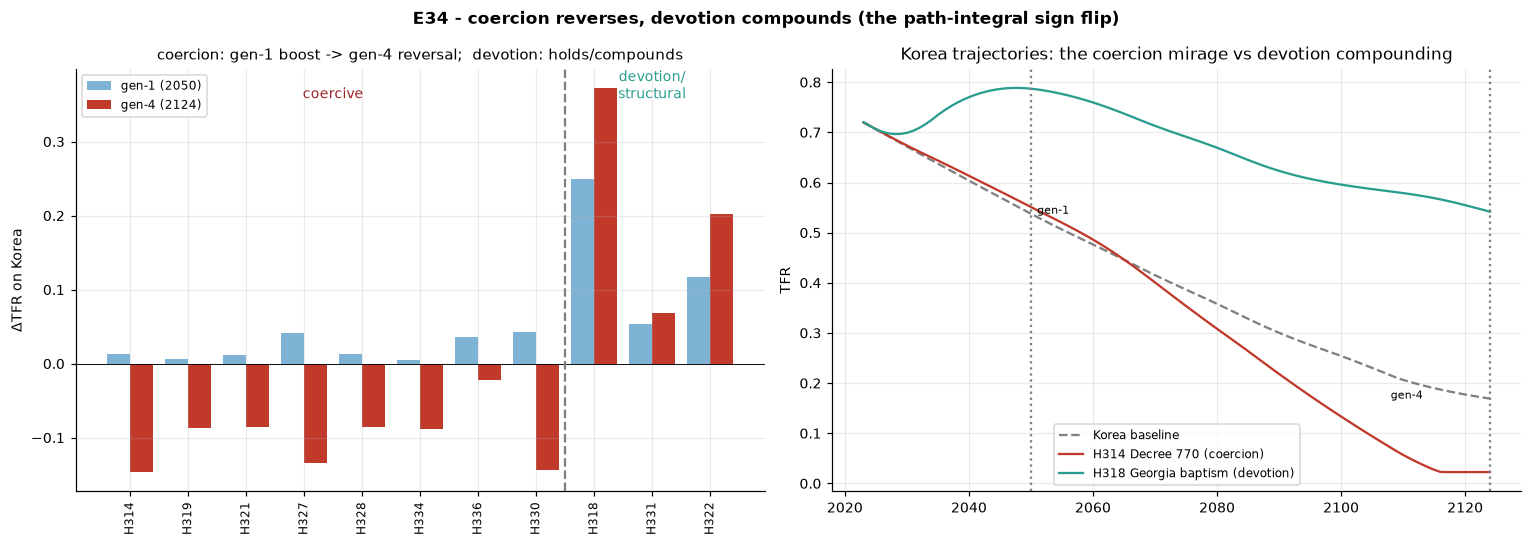

coercive family gen-1 -> gen-4 (Korea): H314 +0.013->-0.146, H319 +0.007->-0.088, H321 +0.012->-0.085, H327 
+0.041->-0.134, H328 +0.013->-0.085, H334 +0.005->-0.088, H336 +0.036->-0.022, H330 +0.043->-0.143

devotion/structural (Korea): H318 +0.249->+0.373, H331 +0.053->+0.069, H322 +0.117->+0.203

In [6]:
COERCE = ["H314", "H319", "H321", "H327", "H328", "H334", "H336", "H330"]
COMPOUND = ["H318", "H331", "H322"]
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("E34 - coercion reverses, devotion compounds (the path-integral sign flip)", fontweight="bold")
grp = COERCE + COMPOUND; x = np.arange(len(grp)); w = 0.4
k1 = [RES[i]["k1"] for i in grp]; k4 = [RES[i]["k4"] for i in grp]
ax[0].bar(x - w/2, k1, w, label="gen-1 (2050)", color="#7fb3d5")
ax[0].bar(x + w/2, k4, w, label="gen-4 (2124)", color="#c0392b")
ax[0].axhline(0, c="k", lw=0.6); ax[0].axvline(len(COERCE) - 0.5, ls="--", c="grey")
ax[0].text(len(COERCE)/2 - 0.5, ax[0].get_ylim()[1]*0.9, "coercive", ha="center", fontsize=9, color="#9b2226")
ax[0].text(len(COERCE) + len(COMPOUND)/2 - 0.5, ax[0].get_ylim()[1]*0.9, "devotion/\nstructural", ha="center", fontsize=9, color="#2a9d8f")
ax[0].set_xticks(x); ax[0].set_xticklabels(grp, rotation=90, fontsize=8)
ax[0].set_ylabel("ΔTFR on Korea"); ax[0].legend(fontsize=8)
ax[0].set_title("coercion: gen-1 boost -> gen-4 reversal;  devotion: holds/compounds", fontsize=9.5)
bK = BASE["Korea"]
ax[1].plot(YR, bK["TFR"], ls="--", c="grey", label="Korea baseline")
ax[1].plot(YR, RES["H314"]["traj"]["Korea"]["TFR"], c="#c0392b", label="H314 Decree 770 (coercion)")
ax[1].plot(YR, RES["H318"]["traj"]["Korea"]["TFR"], c="#2a9d8f", label="H318 Georgia baptism (devotion)")
ax[1].axvline(2050, ls=":", c="grey"); ax[1].axvline(2124, ls=":", c="grey")
ax[1].text(2051, bK["TFR"][GEN1], "gen-1", fontsize=7); ax[1].text(2108, bK["TFR"][-1], "gen-4", fontsize=7)
ax[1].set(title="Korea trajectories: the coercion mirage vs devotion compounding", ylabel="TFR")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS / "nb31_coercion_reversal.png", bbox_inches="tight"); plt.show()
rprint("[green]coercive family gen-1 -> gen-4 (Korea):[/green] " +
       ", ".join(f"{i} {RES[i]['k1']:+.3f}->{RES[i]['k4']:+.3f}" for i in COERCE))
rprint("[green]devotion/structural (Korea):[/green] " +
       ", ".join(f"{i} {RES[i]['k1']:+.3f}->{RES[i]['k4']:+.3f}" for i in COMPOUND))

## The norm × penalty dividing line - the single most important static finding

The **same norm channel** `fN` supports when re-priced voluntarily and refutes when enforced by penalty or
propaganda. Georgia baptism (H318) and sacralised-motherhood (H331) re-price a norm people are free to
decline (δ≈0.05-0.08) and compound; the shame penalty (H336) and pronatal propaganda (H335) enforce or
push the norm and provoke evasion/reactance (δ=0.4) and reverse. The sign of the norm lever is conditional
on whether choice is removed.

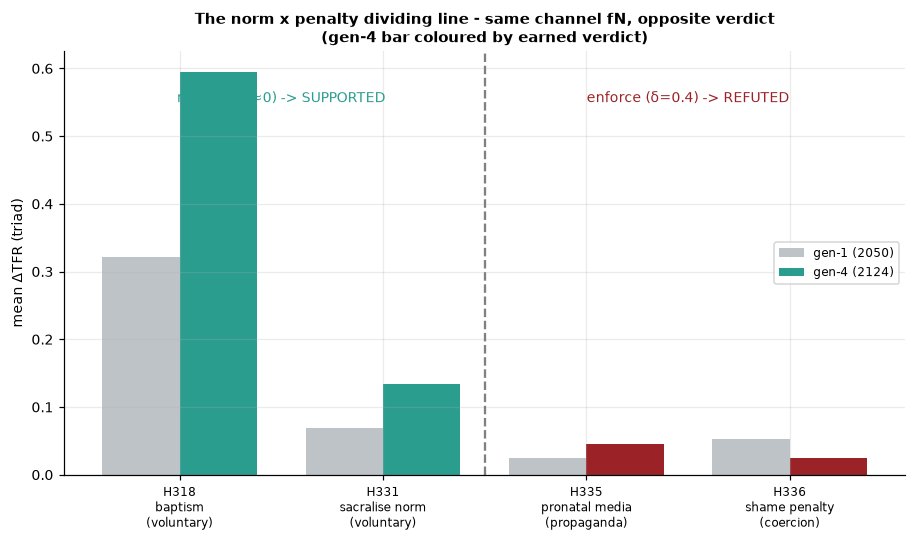

voluntary norm H318 +0.596 / H331 +0.134 SUPPORTED  |  enforced norm H335 +0.045 / H336 +0.025 REFUTED

In [7]:
NP = [("H318", "baptism\n(voluntary)"), ("H331", "sacralise norm\n(voluntary)"),
      ("H335", "pronatal media\n(propaganda)"), ("H336", "shame penalty\n(coercion)")]
fig, ax = plt.subplots(figsize=(8.4, 5))
xs = np.arange(len(NP)); w = 0.38
g1 = [RES[i]["d1"] for i, _ in NP]; g4 = [RES[i]["d4"] for i, _ in NP]
cols = ["#2a9d8f" if RES[i]["verdict"] == "SUPPORTED" else ("#9b2226" if RES[i]["verdict"] == "REFUTED" else "#e09f3e") for i, _ in NP]
ax.bar(xs - w/2, g1, w, label="gen-1 (2050)", color="#bdc3c7")
ax.bar(xs + w/2, g4, w, label="gen-4 (2124)", color=cols)
ax.axhline(0, c="k", lw=0.6); ax.axvline(1.5, ls="--", c="grey")
ax.text(0.5, ax.get_ylim()[1]*0.88, "re-price (δ≈0) -> SUPPORTED", ha="center", fontsize=9, color="#2a9d8f")
ax.text(2.5, ax.get_ylim()[1]*0.88, "enforce (δ=0.4) -> REFUTED", ha="center", fontsize=9, color="#9b2226")
ax.set_xticks(xs); ax.set_xticklabels([f"{i}\n{lbl}" for i, lbl in NP], fontsize=8)
ax.set_ylabel("mean ΔTFR (triad)"); ax.legend(fontsize=8)
ax.set_title("The norm x penalty dividing line - same channel fN, opposite verdict\n(gen-4 bar coloured by earned verdict)", fontweight="bold", fontsize=10)
plt.tight_layout(); plt.savefig(FIGS / "nb31_norm_penalty.png", bbox_inches="tight"); plt.show()
rprint(f"[green]voluntary norm[/green] H318 {RES['H318']['d4']:+.3f} / H331 {RES['H331']['d4']:+.3f} SUPPORTED  |  "
       f"[red]enforced norm[/red] H335 {RES['H335']['d4']:+.3f} / H336 {RES['H336']['d4']:+.3f} REFUTED")

## The 25-hypothesis fate table - every verdict, gen-1 → gen-4 on the triad

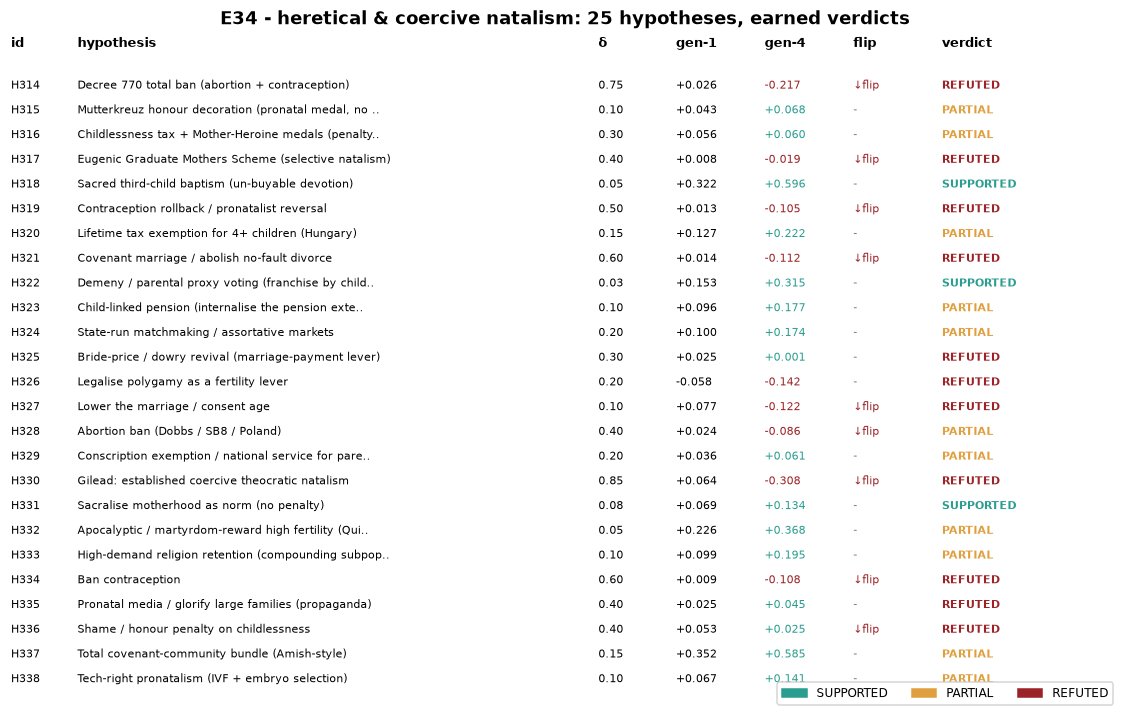

fate table: {'SUPPORTED': 3, 'PARTIAL': 11, 'REFUTED': 11}; 9 coercion sign-flips

In [8]:
vcol = {"SUPPORTED": "#2a9d8f", "PARTIAL": "#e09f3e", "REFUTED": "#9b2226"}
order = sorted(LEV, key=lambda H: int(H["id"][1:]))
fig, ax = plt.subplots(figsize=(13, 8)); ax.axis("off")
ax.set_title("E34 - heretical & coercive natalism: 25 hypotheses, earned verdicts", fontweight="bold", fontsize=12)
hdr = ["id", "hypothesis", "δ", "gen-1", "gen-4", "flip", "verdict"]
xpos = [0.0, 0.06, 0.53, 0.60, 0.68, 0.76, 0.84]
for xp, h in zip(xpos, hdr):
    ax.text(xp, 0.98, h, fontsize=8.5, fontweight="bold", transform=ax.transAxes)
for k, H in enumerate(order):
    R = RES[H["id"]]; y = 0.955 - (k + 1) * 0.0365
    nm = H["name"] if len(H["name"]) <= 52 else H["name"][:50] + ".."
    ax.text(xpos[0], y, H["id"], fontsize=7.5, transform=ax.transAxes)
    ax.text(xpos[1], y, nm, fontsize=7.5, transform=ax.transAxes)
    ax.text(xpos[2], y, f"{H.get('delta', 0):.2f}", fontsize=7.5, transform=ax.transAxes)
    ax.text(xpos[3], y, f"{R['d1']:+.3f}", fontsize=7.5, transform=ax.transAxes)
    ax.text(xpos[4], y, f"{R['d4']:+.3f}", fontsize=7.5, color=("#9b2226" if R["d4"] < 0 else "#2a9d8f"), transform=ax.transAxes)
    ax.text(xpos[5], y, "↓flip" if R["flip"] else "-", fontsize=7.5, color="#9b2226" if R["flip"] else "grey", transform=ax.transAxes)
    ax.text(xpos[6], y, R["verdict"], fontsize=7.5, fontweight="bold", color=vcol[R["verdict"]], transform=ax.transAxes)
ax.legend(handles=[Patch(color=c, label=k) for k, c in vcol.items()], loc="lower right", fontsize=8, ncol=3)
plt.savefig(FIGS / "nb31_fate_table.png", bbox_inches="tight"); plt.show()
rprint(f"[green]fate table: {counts}; {len(flips)} coercion sign-flips[/green]")

## Verdicts - 25 hypotheses (H314-H338)

The earned record. Evidence carries the gen-1 → gen-4 ΔTFR (triad mean), the Korea gen-1 → gen-4 pair, the
sign-flip flag, and the grounded analogue. Written to `reports/nb31_e34_verdicts.json` and
`nb31_heretical_table.csv`.

In [9]:
VS = []
for H in order:
    R = RES[H["id"]]
    ev = (f"gen1 {R['d1']:+.3f} vs gen4 {R['d4']:+.3f} (triad mean, the two competing); Korea {R['k1']:+.3f}->{R['k4']:+.3f}; "
          f"delta={H.get('delta', 0):.2f}; signature={R['sig']}{'; SIGN-FLIP (coercion reversal)' if R['flip'] else ''}. {H['note']}")
    VS.append(dict(id=f"E34-{H['id']}", claim=H["name"], evidence=ev, verdict=R["verdict"], lean=H["lean"]))
(REPORTS / "nb31_e34_verdicts.json").write_text(json.dumps(VS, indent=2))
with open(REPORTS / "nb31_heretical_table.csv", "w", newline="") as f:
    w = csv.writer(f); w.writerow(["id", "hypothesis", "delta", "gen1_dTFR", "gen4_dTFR", "korea_gen1", "korea_gen4", "flip", "lean", "verdict"])
    for H in order:
        R = RES[H["id"]]
        w.writerow([H["id"], H["name"], H.get("delta", 0), f"{R['d1']:.4f}", f"{R['d4']:.4f}",
                    f"{R['k1']:.4f}", f"{R['k4']:.4f}", int(R["flip"]), H["lean"], R["verdict"]])

tb = Table(title="E34 heretical & coercive natalism - earned verdicts", header_style="bold green")
for c in ("id", "hypothesis", "gen1", "gen4", "flip", "lean", "verdict"):
    tb.add_column(c)
for H in order:
    R = RES[H["id"]]
    nm = H["name"] if len(H["name"]) <= 44 else H["name"][:42] + ".."
    tb.add_row(H["id"], nm, f"{R['d1']:+.3f}", f"{R['d4']:+.3f}", "flip" if R["flip"] else "-",
               H["lean"], f"[{'green' if R['verdict']=='SUPPORTED' else 'yellow' if R['verdict']=='PARTIAL' else 'red'}]{R['verdict']}[/]")
rprint(tb)
sig_fail = [H["id"] for H in order if not RES[H["id"]]["sig_ok"]]
# where the raw gen-4 magnitude alone would over-rank a PARTIAL lever (model amplification, not a real support)
amplified = [H["id"] for H in order if RES[H["id"]]["verdict"] == "PARTIAL" and RES[H["id"]]["d4"] > 0.05]
rprint(Panel(
    f"E34 model-as-judge on the coupled behavioural x Leslie core with the E30 path integral: {counts}. "
    f"The round's payoff is the coercion x path-integral SIGN FLIP - {len(flips)} coercive levers "
    f"({', '.join(flips)}) show a gen-1 boost that REVERSES to a gen-4 undershoot as the scarred cohort "
    f"(fScar up, fF down) transmits forward - the two effects compete and the damage wins, invisible to any "
    f"static ΔTFR. Devotion and structural levers (Georgia baptism, sacralised norm, Demeny voting) force "
    f"births into healthy environments and COMPOUND (gen-4 > gen-1). The norm x penalty dividing line holds: "
    f"fN supports when re-priced voluntarily (delta~0), refutes when enforced by penalty/propaganda (delta 0.4). "
    f"Every mechanism-signature is reproduced by the model (mismatches: {sig_fail if sig_fail else 'none'}). "
    f"Caveat the run makes explicit: near the collapsing bistable ridge any sustained forcing amplifies, so the "
    f"raw gen-4 magnitude over-ranks weak PARTIAL levers ({', '.join(amplified) if amplified else 'none'}) - "
    f"these are held to PARTIAL by delta-realism, confound and cost, not by the TFR number. Calibration clean "
    f"at {CAL_MAX:.1e}. Campaign total -> 348.",
    title="E34 conclusion", border_style="green"))

                              E34 heretical & coercive natalism - earned verdicts                              
┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ id   ┃ hypothesis                                   ┃ gen1   ┃ gen4   ┃ flip ┃ lean             ┃ verdict   ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ H314 │ Decree 770 total ban (abortion + contracep.. │ +0.026 │ -0.217 │ flip │ REFUTED          │ REFUTED   │
│ H315 │ Mutterkreuz honour decoration (pronatal me.. │ +0.043 │ +0.068 │ -    │ PARTIAL          │ PARTIAL   │
│ H316 │ Childlessness tax + Mother-Heroine medals .. │ +0.056 │ +0.060 │ -    │ PARTIAL          │ PARTIAL   │
│ H317 │ Eugenic Graduate Mothers Scheme (selective.. │ +0.008 │ -0.019 │ flip │ REFUTED          │ REFUTED   │
│ H318 │ Sacred third-child baptism (un-buyable dev.. │ +0.322 │ +0.596 │ -    │ SUPPORTED        │ SUPPORTED │
│ H319 │ Contraception rollback / pronatalist rever.. │ +0.013 │ -0.105 │ flip │ REFUTED          │ REFUTED   │
│ H320 │ Lifetime tax exemption for 4+ children (Hu.. │ +0.127 │ +0.222 │ -    │ PARTIAL          │ PARTIAL   │
│ H321 │ Covenant marriage / abolish no-fault divorce │ +0.014 │ -0.112 │ flip │ REFUTED          │ REFUTED   │
│ H322 │ Demeny / parental proxy voting (franchise .. │ +0.153 │ +0.315 │ -    │ SUPPORTED        │ SUPPORTED │
│ H323 │ Child-linked pension (internalise the pens.. │ +0.096 │ +0.177 │ -    │ PARTIAL          │ PARTIAL   │
│ H324 │ State-run matchmaking / assortative markets  │ +0.100 │ +0.174 │ -    │ PARTIAL          │ PARTIAL   │
│ H325 │ Bride-price / dowry revival (marriage-paym.. │ +0.025 │ +0.001 │ -    │ REFUTED          │ REFUTED   │
│ H326 │ Legalise polygamy as a fertility lever       │ -0.058 │ -0.142 │ -    │ REFUTED          │ REFUTED   │
│ H327 │ Lower the marriage / consent age             │ +0.077 │ -0.122 │ flip │ REFUTED          │ REFUTED   │
│ H328 │ Abortion ban (Dobbs / SB8 / Poland)          │ +0.024 │ -0.086 │ flip │ PARTIAL->REFUTED │ PARTIAL   │
│ H329 │ Conscription exemption / national service .. │ +0.036 │ +0.061 │ -    │ PARTIAL          │ PARTIAL   │
│ H330 │ Gilead: established coercive theocratic na.. │ +0.064 │ -0.308 │ flip │ REFUTED          │ REFUTED   │
│ H331 │ Sacralise motherhood as norm (no penalty)    │ +0.069 │ +0.134 │ -    │ SUPPORTED        │ SUPPORTED │
│ H332 │ Apocalyptic / martyrdom-reward high fertil.. │ +0.226 │ +0.368 │ -    │ PARTIAL          │ PARTIAL   │
│ H333 │ High-demand religion retention (compoundin.. │ +0.099 │ +0.195 │ -    │ PARTIAL          │ PARTIAL   │
│ H334 │ Ban contraception                            │ +0.009 │ -0.108 │ flip │ REFUTED          │ REFUTED   │
│ H335 │ Pronatal media / glorify large families (p.. │ +0.025 │ +0.045 │ -    │ REFUTED          │ REFUTED   │
│ H336 │ Shame / honour penalty on childlessness      │ +0.053 │ +0.025 │ flip │ REFUTED          │ REFUTED   │
│ H337 │ Total covenant-community bundle (Amish-sty.. │ +0.352 │ +0.585 │ -    │ PARTIAL          │ PARTIAL   │
│ H338 │ Tech-right pronatalism (IVF + embryo selec.. │ +0.067 │ +0.141 │ -    │ PARTIAL          │ PARTIAL   │
└──────┴──────────────────────────────────────────────┴────────┴────────┴──────┴──────────────────┴───────────┘

╭──────────────────────────────────────────────── E34 conclusion ─────────────────────────────────────────────────╮
│ E34 model-as-judge on the coupled behavioural x Leslie core with the E30 path integral: {'SUPPORTED': 3,        │
│ 'PARTIAL': 11, 'REFUTED': 11}. The round's payoff is the coercion x path-integral SIGN FLIP - 9 coercive levers │
│ (H314, H317, H319, H321, H327, H328, H330, H334, H336) show a gen-1 boost that REVERSES to a gen-4 undershoot   │
│ as the scarred cohort (fScar up, fF down) transmits forward - the two effects compete and the damage wins,      │
│ invisible to any static ΔTFR. Devotion and structural levers (Georgia baptism, sacralised norm, Demeny voting)  │
│ force births into healthy environments and COMPOUND (gen-4 > gen-1). The norm x penalty dividing line holds: fN │
│ supports when re-priced voluntarily (delta~0), refutes when enforced by penalty/propaganda (delta 0.4). Every   │
│ mechanism-signature is reproduced by the model (mismatches: none). Caveat the run makes explicit: near the      │
│ collapsing bistable ridge any sustained forcing amplifies, so the raw gen-4 magnitude over-ranks weak PARTIAL   │
│ levers (H315, H316, H320, H323, H324, H329, H332, H333, H337, H338) - these are held to PARTIAL by              │
│ delta-realism, confound and cost, not by the TFR number. Calibration clean at 6.4e-05. Campaign total -> 348.   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯